In [ ]:
# Then use the copied path from the folder icon
import pandas as pd
df = pd.read_csv('/Data/full_data.csv')

In [32]:
df.head()

,Unnamed: 0,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [33]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [27]:
# Shape
print("Shape:", df.shape)

Shape: (199523, 43)


In [8]:
# Standard nulls
print(df.isnull().sum())

Unnamed: 0                                      0
age                                             0
class of worker                                 0
detailed industry recode                        0
detailed occupation recode                      0
education                                       0
wage per hour                                   0
enroll in edu inst last wk                      0
marital stat                                    0
major industry code                             0
major occupation code                           0
race                                            0
hispanic origin                               874
sex                                             0
member of a labor union                         0
reason for unemployment                         0
full or part time employment stat               0
capital gains                                   0
capital losses                                  0
dividends from stocks                           0


REMOVE NULL VALUES

In [9]:
# Hidden missing values (common in census data)
print((df == '?').sum())

Unnamed: 0                                        0
age                                               0
class of worker                                   0
detailed industry recode                          0
detailed occupation recode                        0
education                                         0
wage per hour                                     0
enroll in edu inst last wk                        0
marital stat                                      0
major industry code                               0
major occupation code                             0
race                                              0
hispanic origin                                   0
sex                                               0
member of a labor union                           0
reason for unemployment                           0
full or part time employment stat                 0
capital gains                                     0
capital losses                                    0
dividends fr

In [10]:
# Raw distribution
print(df['label'].value_counts())

label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64


In [11]:
# Weighted distribution (true population picture)
weighted = df.groupby('label')['weight'].sum()
print(weighted / weighted.sum() * 100)

label
- 50000.    93.594958
50000+.      6.405042
Name: weight, dtype: float64


In [12]:
import numpy as np
df = df.replace('?', np.nan)

In [13]:
df['hispanic origin'] = df['hispanic origin'].fillna(df['hispanic origin'].mode()[0])

In [14]:
small_missing_cols = [
    'state of previous residence',
    'country of birth father',
    'country of birth mother',
    'country of birth self'
]

for col in small_missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
migration_cols = [
    'migration code-change in msa',
    'migration code-change in reg',
    'migration code-move within reg',
    'migration prev res in sunbelt'
]

df = df.drop(columns=migration_cols)

In [16]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [14]:
print("? values:", (df == '?').sum().sum())

? values: 0


In [15]:
print("Final shape:", df.shape)

Final shape: (199523, 39)


In [ ]:
# Hidden missing values (common in census data)
print((df == '?').sum())

In [17]:
df = df.drop(columns=['Unnamed: 0'])

print(df.shape)

(199523, 38)


Handle White SPaces in the text

In [18]:
print(df['label'].unique())  # might show ' 50000+.' instead of '50000+.'

['- 50000.' '50000+.']


In [19]:
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

# Verify
print(df['label'].unique())

['- 50000.' '50000+.']


ENCODE THE LABEL COLUMN TO 0 and 1

In [20]:
# See current values
print(df['label'].unique())

# Clean to simple 0 and 1
df['label'] = df['label'].str.strip()
df['label'] = df['label'].map({'- 50000.': 0, '50000+.': 1})

print(df['label'].value_counts())

['- 50000.' '50000+.']
label
0    187141
1     12382
Name: count, dtype: int64


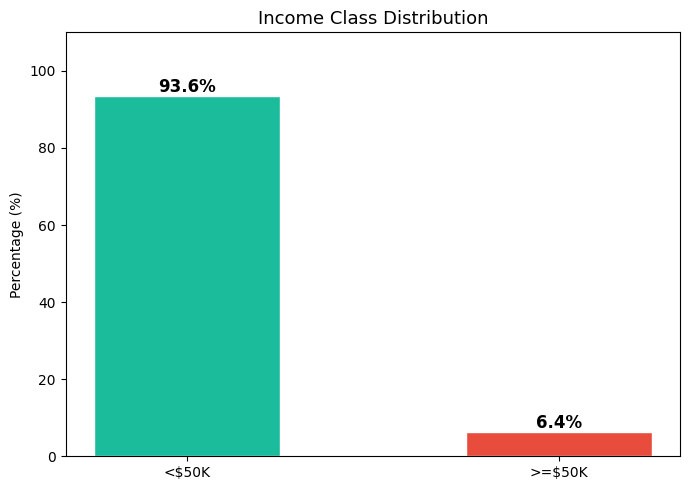

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

labels = ['<$50K', '>=$50K']
pcts = [93.6, 6.4]
colors = ['#1abc9c', '#e74c3c']

bars = ax.bar(labels, pcts, color=colors, edgecolor='white', width=0.5)

for bar, v in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{v}%', ha='center', fontsize=12, fontweight='bold')

ax.set_title('Income Class Distribution', fontsize=13)
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()

In [21]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 3356


In [22]:
# See what the duplicates look like
duplicates = df[df.duplicated()]
print(duplicates.shape)

(3356, 38)


In [ ]:
print(duplicates.head(10))

CHECK FOR DATA TYPES NOW

In [ ]:
print(df.dtypes)

In [25]:
# Check unique values of suspicious columns
suspicious_cols = [
    'detailed industry recode',
    'detailed occupation recode',
    'own business or self employed',
    'veterans benefits',
    'year',
    'family members under 18'
]

for col in suspicious_cols:
    print(f"\n{col}:")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].unique())


detailed industry recode:
Unique values: 52
[ 0  4 40 34 43 37 24 39 12 35 45  3 19 29 32 48 33 23 44 36 31 30 41  5
 11  9 42  6 18 50  2  1 26 47 16 14 22 17  7  8 25 46 27 15 13 49 38 21
 28 20 51 10]

detailed occupation recode:
Unique values: 47
[ 0 34 10  3 40 26 37 31 12 36 41 22  2 35 25 23 42  8 19 29 27 16 33 13
 18  9 17 39 32 11 30 38 20  7 21 44 24 43 28  4  1  6 45 14  5 15 46]

own business or self employed:
Unique values: 3
[0 2 1]

veterans benefits:
Unique values: 3
[2 0 1]

year:
Unique values: 2
[95 94]

family members under 18:
Unique values: 5
['Not in universe' 'Both parents present' 'Mother only present'
 'Neither parent present' 'Father only present']


In [26]:
suspicious_cols = [
    'detailed occupation recode',
    'own business or self employed',
    'veterans benefits',
    'year'
]

for col in suspicious_cols:
    print(f"\n{col}:")
    print(f"Unique values: {df[col].nunique()}")



detailed occupation recode:
Unique values: 47

own business or self employed:
Unique values: 3

veterans benefits:
Unique values: 3

year:
Unique values: 2


In [27]:
for col in suspicious_cols:
  print(f"Values: {sorted(df[col].unique())}")


Values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46)]
Values: [np.int64(0), np.int64(1), np.int64(2)]
Values: [np.int64(0), np.int64(1), np.int64(2)]
Values: [np.int64(94), np.int64(95)]


In [28]:
 for col in suspicious_cols:
  print(f"Value counts:\n{df[col].value_counts()}")

Value counts:
detailed occupation recode
0     100684
2       8756
26      7887
19      5413
29      5105
36      4145
34      4025
10      3683
16      3445
23      3392
12      3340
33      3325
3       3195
35      3168
38      3003
31      2699
32      2398
37      2234
8       2151
42      1918
30      1897
24      1847
17      1771
28      1661
44      1592
41      1592
43      1382
4       1364
13      1271
18      1083
39      1017
14       932
5        855
15       815
27       780
25       767
9        738
7        731
11       637
40       617
1        544
21       533
6        441
22       411
45       172
20        71
46        36
Name: count, dtype: int64
Value counts:
own business or self employed
0    180672
2     16153
1      2698
Name: count, dtype: int64
Value counts:
veterans benefits
2    150130
0     47409
1      1984
Name: count, dtype: int64
Value counts:
year
94    99827
95    99696
Name: count, dtype: int64


CHeck if veterans benefit acctually affects income

In [29]:
# Check if veterans benefits relates to income
vet_income = df.groupby(['veterans benefits', 'label'])['weight'].sum().unstack()
vet_income.columns = ['<50k', '>50k']
vet_income['pct_high_income'] = vet_income['>50k'] / vet_income.sum(axis=1) * 100
print(vet_income)

                           <50k         >50k  pct_high_income
veterans benefits                                            
0                  7.907788e+07          NaN              NaN
1                  3.065078e+06    412753.85        11.868138
2                  2.428617e+08  21828491.40         8.246808


In [30]:
# Let's investigate code 0 more closely
print(df[df['veterans benefits'] == 0]['label'].value_counts())

label
0    47409
Name: count, dtype: int64


In [31]:
# Check if year relates to income
year_income = df.groupby(['year', 'label'])['weight'].sum().unstack()
year_income.columns = ['<50k', '>50k']
year_income['pct_high_income'] = year_income['>50k'] / year_income.sum(axis=1) * 100
print(year_income)

              <50k         >50k  pct_high_income
year                                            
94    1.621055e+08  10465115.70         6.064252
95    1.628992e+08  11776129.55         6.741725


In [32]:
# Drop year column
df = df.drop(columns=['year'])

# Verify
print("Final shape after dropping year:", df.shape)
print("\nRemaining columns:", df.columns.tolist())

Final shape after dropping year: (199523, 37)

Remaining columns: ['age', 'class of worker', 'detailed industry recode', 'detailed occupation recode', 'education', 'wage per hour', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'capital gains', 'capital losses', 'dividends from stocks', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'weight', 'live in this house 1 year ago', 'num persons worked for employer', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's admin", 'veterans benefits', 'weeks worked in year', 'label']


Analyzing numerical columns first

In [33]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns:", num_cols)
print("Count:", len(num_cols))

Numerical columns: ['age', 'detailed industry recode', 'detailed occupation recode', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks', 'weight', 'num persons worked for employer', 'own business or self employed', 'veterans benefits', 'weeks worked in year', 'label']
Count: 13


In [34]:
num_cols = [
    'age',
    'wage per hour',
    'capital gains',
    'capital losses',
    'dividends from stocks',
    'num persons worked for employer',
    'weeks worked in year'
]

print("True numerical columns:", num_cols)
print("Count:", len(num_cols))

True numerical columns: ['age', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks', 'num persons worked for employer', 'weeks worked in year']
Count: 7


In [35]:
print(df[num_cols].describe())

                 age  wage per hour  capital gains  capital losses  \
count  199523.000000  199523.000000   199523.00000   199523.000000   
mean       34.494199      55.426908      434.71899       37.313788   
std        22.310895     274.896454     4697.53128      271.896428   
min         0.000000       0.000000        0.00000        0.000000   
25%        15.000000       0.000000        0.00000        0.000000   
50%        33.000000       0.000000        0.00000        0.000000   
75%        50.000000       0.000000        0.00000        0.000000   
max        90.000000    9999.000000    99999.00000     4608.000000   

       dividends from stocks  num persons worked for employer  \
count          199523.000000                    199523.000000   
mean              197.529533                         1.956180   
std              1984.163658                         2.365126   
min                 0.000000                         0.000000   
25%                 0.000000                

Analyze the age if its relevant to keep the people below 18 years

In [36]:
# Basic stats
print("Age Statistics:")
print(df['age'].describe())

# Distribution of ages
print("\nAge value counts (grouped):")
print(pd.cut(df['age'], bins=[0,10,18,25,35,45,55,65,90]).value_counts().sort_index())

# How many children under 18?
print("\nPeople under 18:", (df['age'] < 18).sum())
print("Percentage:", (df['age'] < 18).sum() / len(df) * 100)

# How many under 18 earn >50k?
print("\nUnder 18 income distribution:")
print(df[df['age'] < 18]['label'].value_counts())

Age Statistics:
count    199523.000000
mean         34.494199
std          22.310895
min           0.000000
25%          15.000000
50%          33.000000
75%          50.000000
max          90.000000
Name: age, dtype: float64

Age value counts (grouped):
age
(0, 10]     32175
(10, 18]    23462
(18, 25]    18123
(25, 35]    31556
(35, 45]    30817
(45, 55]    22082
(55, 65]    15730
(65, 90]    22739
Name: count, dtype: int64

People under 18: 55992
Percentage: 28.0629300882605

Under 18 income distribution:
label
0    55990
1        2
Name: count, dtype: int64


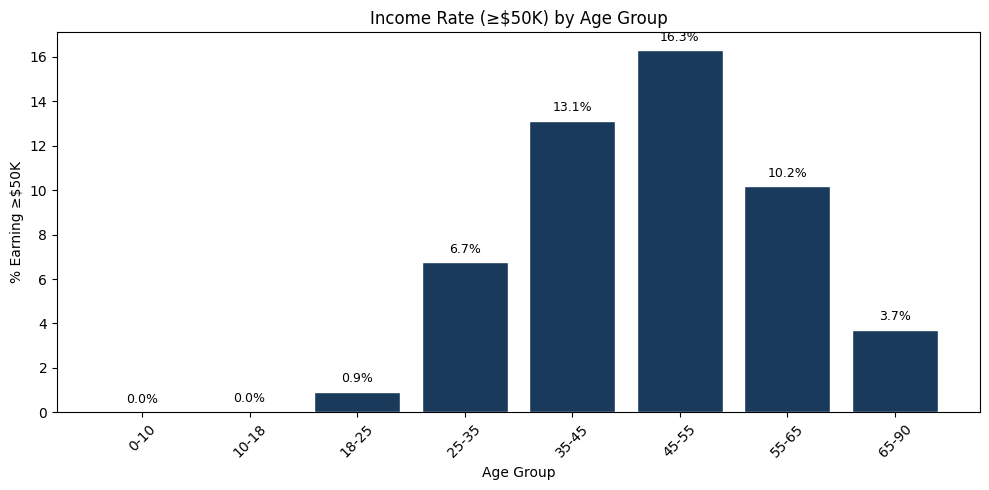

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Create age groups
age_bins = [0, 10, 18, 25, 35, 45, 55, 65, 90]
age_labels = ['0-10', '10-18', '18-25', '25-35', '35-45', '45-55', '55-65', '65-90']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Calculate income rate per age group
income_by_age = df.groupby('age_group', observed=True)['label'].mean() * 100

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(income_by_age.index, income_by_age.values, color='#1a3a5c', edgecolor='white')

# Add value labels on top of each bar
for bar, val in zip(bars, income_by_age.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.title('Income Rate (≥$50K) by Age Group')
plt.xlabel('Age Group')
plt.ylabel('% Earning ≥$50K')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

WAGE COLUMN

In [ ]:
print("Wage Per Hour Statistics:")
print(df['wage per hour'].describe())

print("\nHow many people have zero wage?")
print((df['wage per hour'] == 0).sum())
print("Percentage:", (df['wage per hour'] == 0).sum() / len(df) * 100)

print("\nHow many people have wage = 9999?")
print((df['wage per hour'] == 9999).sum())

print("\nWage distribution among >50k earners vs <50k earners:")
print(df.groupby('label')['wage per hour'].describe())

Wage Per Hour Statistics:
count    199523.000000
mean         55.426908
std         274.896454
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        9999.000000
Name: wage per hour, dtype: float64

How many people have zero wage?
188219
Percentage: 94.3344877532916

How many people have wage = 9999?
1

Wage distribution among >50k earners vs <50k earners:
          count       mean         std  min  25%  50%  75%     max
label                                                             
0      187141.0  53.692526  261.168380  0.0  0.0  0.0  0.0  9916.0
1       12382.0  81.640284  431.364773  0.0  0.0  0.0  0.0  9999.0


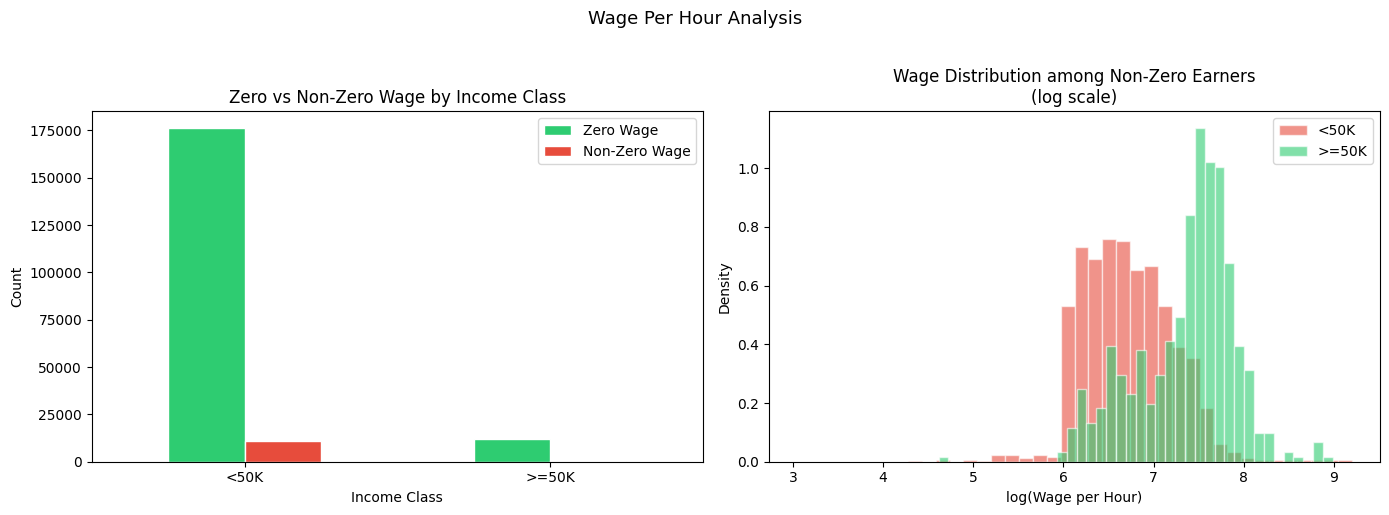

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color palette
colors = ['#2ecc71', '#e74c3c']  # green and red

# Plot 1: Zero vs Non-Zero wage split by income class
zero_nonzero = pd.DataFrame({
    '<50K': [
        (df[df['label']==0]['wage per hour']==0).sum(),
        (df[df['label']==0]['wage per hour']!=0).sum()
    ],
    '>=50K': [
        (df[df['label']==1]['wage per hour']==0).sum(),
        (df[df['label']==1]['wage per hour']!=0).sum()
    ]
}, index=['Zero Wage', 'Non-Zero Wage'])

zero_nonzero.T.plot(kind='bar', ax=axes[0],
                    color=colors,
                    edgecolor='white')
axes[0].set_title('Zero vs Non-Zero Wage by Income Class')
axes[0].set_xlabel('Income Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['<50K', '>=50K'], rotation=0)
axes[0].legend(['Zero Wage', 'Non-Zero Wage'])

# Plot 2: Distribution of non-zero wages by income class
colors2 = ['#e74c3c', '#2ecc71']
for (label, color, name) in [(0, '#e74c3c', '<50K'), (1, '#2ecc71', '>=50K')]:
    data = df[(df['label']==label) &
              (df['wage per hour']>0) &
              (df['wage per hour']<9999)]['wage per hour']
    axes[1].hist(np.log1p(data), bins=40, alpha=0.6,
                 color=color, label=name, density=True,
                 edgecolor='white')

axes[1].set_title('Wage Distribution among Non-Zero Earners\n(log scale)')
axes[1].set_xlabel('log(Wage per Hour)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Wage Per Hour Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Capital GAIN

In [48]:
print("Capital Gains Statistics:")
print(df['capital gains'].describe())

print("\nHow many people have zero capital gains?")
print((df['capital gains'] == 0).sum())
print("Percentage:", (df['capital gains'] == 0).sum() / len(df) * 100)

print("\nHow many people have capital gains = 99999?")
print((df['capital gains'] == 99999).sum())

print("\nCapital gains distribution among income groups:")
print(df.groupby('label')['capital gains'].describe())

Capital Gains Statistics:
count    199523.00000
mean        434.71899
std        4697.53128
min           0.00000
25%           0.00000
50%           0.00000
75%           0.00000
max       99999.00000
Name: capital gains, dtype: float64

How many people have zero capital gains?
192144
Percentage: 96.30167950562091

How many people have capital gains = 99999?
390

Capital gains distribution among income groups:
          count         mean           std  min  25%  50%  75%      max
label                                                                  
0      187141.0   143.848013   1815.343341  0.0  0.0  0.0  0.0  99999.0
1       12382.0  4830.930060  16887.627002  0.0  0.0  0.0  0.0  99999.0


CAPITAL LOSSES

In [49]:
print("Capital Losses Statistics:")
print(df['capital losses'].describe())

print("\nHow many people have zero capital losses?")
print((df['capital losses'] == 0).sum())
print("Percentage:", (df['capital losses'] == 0).sum() / len(df) * 100)

print("\nHow many people have capital losses = 4608?")
print((df['capital losses'] == 4608).sum())

print("\nCapital losses distribution among income groups:")
print(df.groupby('label')['capital losses'].describe())

Capital Losses Statistics:
count    199523.000000
mean         37.313788
std         271.896428
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        4608.000000
Name: capital losses, dtype: float64

How many people have zero capital losses?
195617
Percentage: 98.04233095933802

How many people have capital losses = 4608?
4

Capital losses distribution among income groups:
          count        mean         std  min  25%  50%  75%     max
label                                                              
0      187141.0   27.003730  229.535067  0.0  0.0  0.0  0.0  4608.0
1       12382.0  193.139557  607.542507  0.0  0.0  0.0  0.0  3683.0


Dividends From Stocks Analysis:

In [50]:
print("Dividends From Stocks Statistics:")
print(df['dividends from stocks'].describe())

print("\nHow many people have zero dividends?")
print((df['dividends from stocks'] == 0).sum())
print("Percentage:", (df['dividends from stocks'] == 0).sum() / len(df) * 100)

print("\nHow many people have dividends = 99999?")
print((df['dividends from stocks'] == 99999).sum())

print("\nDividends distribution among income groups:")
print(df.groupby('label')['dividends from stocks'].describe())

Dividends From Stocks Statistics:
count    199523.000000
mean        197.529533
std        1984.163658
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       99999.000000
Name: dividends from stocks, dtype: float64

How many people have zero dividends?
178382
Percentage: 89.40422908637099

How many people have dividends = 99999?
25

Dividends distribution among income groups:
          count         mean          std  min  25%  50%    75%      max
label                                                                   
0      187141.0   107.816518   909.774217  0.0  0.0  0.0    0.0  39000.0
1       12382.0  1553.448070  6998.071762  0.0  0.0  0.0  363.0  99999.0


In [52]:

df['total investment income'] = (df['capital gains'] -
                                  df['capital losses'] +
                                  df['dividends from stocks'])

# Verify
print("Total investment income statistics:")
print(df['total investment income'].describe())

print("\nCorrelation with label:")
print(df['total investment income'].corr(df['label']))

Total investment income statistics:
count    199523.000000
mean        594.934734
std        5339.960948
min       -4608.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      199998.000000
Name: total investment income, dtype: float64

Correlation with label:
0.2695722724606996


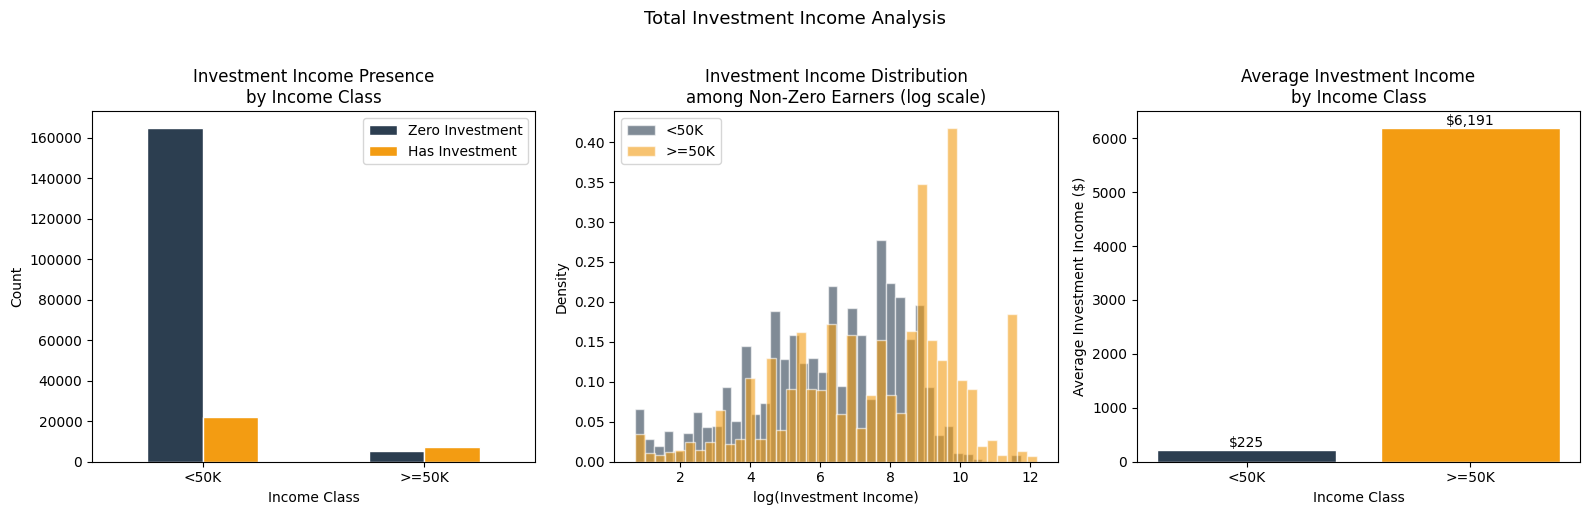

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Zero vs Non-Zero investment income by income class
zero_inv = pd.DataFrame({
    '<50K': [
        (df[df['label']==0]['total investment income']==0).sum(),
        (df[df['label']==0]['total investment income']!=0).sum()
    ],
    '>=50K': [
        (df[df['label']==1]['total investment income']==0).sum(),
        (df[df['label']==1]['total investment income']!=0).sum()
    ]
}, index=['Zero Investment', 'Has Investment'])

zero_inv.T.plot(kind='bar', ax=axes[0],
                color=['#2c3e50', '#f39c12'],
                edgecolor='white')
axes[0].set_title('Investment Income Presence\nby Income Class')
axes[0].set_xlabel('Income Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['<50K', '>=50K'], rotation=0)
axes[0].legend(['Zero Investment', 'Has Investment'])

# Plot 2: Distribution of non-zero investment income (log scale)
for label, color, name in [(0, '#2c3e50', '<50K'), (1, '#f39c12', '>=50K')]:
    data = df[(df['label']==label) &
              (df['total investment income']>0)]['total investment income']
    axes[1].hist(np.log1p(data), bins=40, alpha=0.6,
                 color=color, label=name, density=True,
                 edgecolor='white')

axes[1].set_title('Investment Income Distribution\namong Non-Zero Earners (log scale)')
axes[1].set_xlabel('log(Investment Income)')
axes[1].set_ylabel('Density')
axes[1].legend()

# Plot 3: Average investment income by income class
avg_inv = df.groupby('label')['total investment income'].mean()
axes[2].bar(['<50K', '>=50K'], avg_inv.values,
            color=['#2c3e50', '#f39c12'],
            edgecolor='white')
axes[2].set_title('Average Investment Income\nby Income Class')
axes[2].set_xlabel('Income Class')
axes[2].set_ylabel('Average Investment Income ($)')

# Add value labels on bars
for i, val in enumerate(avg_inv.values):
    axes[2].text(i, val + 50, f'${val:,.0f}',
                ha='center', fontsize=10)

plt.suptitle('Total Investment Income Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

##does accounting for the survey weight change the numbers meaningfully?

In [ ]:
# Compare raw vs weighted for all numerical columns
num_cols = ['age', 'wage per hour', 'capital gains',
            'capital losses', 'dividends from stocks',
            'weeks worked in year']

for col in num_cols:
    print(f"\n{col}:")
    for label in [0, 1]:
        subset = df[df['label'] == label]
        raw_mean = subset[col].mean()
        w_mean = (subset[col] * subset['weight']).sum() / subset['weight'].sum()
        print(f"  Label {label} → Raw mean: {raw_mean:.2f} | Weighted mean: {w_mean:.2f}")


age:
  Label 0 → Raw mean: 33.72 | Weighted mean: 33.68
  Label 1 → Raw mean: 46.27 | Weighted mean: 46.13

wage per hour:
  Label 0 → Raw mean: 53.69 | Weighted mean: 55.72
  Label 1 → Raw mean: 81.64 | Weighted mean: 81.37

capital gains:
  Label 0 → Raw mean: 143.85 | Weighted mean: 144.57
  Label 1 → Raw mean: 4830.93 | Weighted mean: 4781.24

capital losses:
  Label 0 → Raw mean: 27.00 | Weighted mean: 27.87
  Label 1 → Raw mean: 193.14 | Weighted mean: 194.79

dividends from stocks:
  Label 0 → Raw mean: 107.82 | Weighted mean: 109.48
  Label 1 → Raw mean: 1553.45 | Weighted mean: 1483.94

weeks worked in year:
  Label 0 → Raw mean: 21.53 | Weighted mean: 21.90
  Label 1 → Raw mean: 48.07 | Weighted mean: 48.16


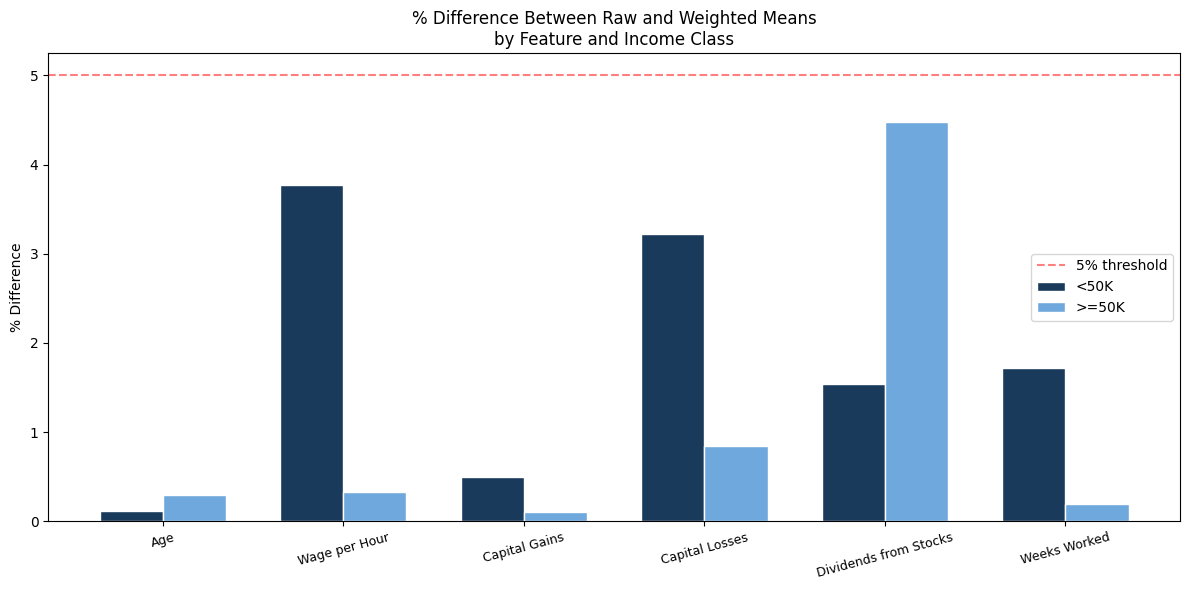

In [1]:
import matplotlib.pyplot as plt
import numpy as np

features = ['Age', 'Wage per Hour', 'Capital Gains',
            'Capital Losses', 'Dividends from Stocks', 'Weeks Worked']

# Percentage difference between raw and weighted
pct_diff_0 = [0.12, 3.77, 0.50, 3.22, 1.54, 1.72]  # <50K class
pct_diff_1 = [0.30, 0.33, 0.10, 0.85, 4.48, 0.19]  # >=50K class

x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, pct_diff_0, width,
               label='<50K', color='#1a3a5c', edgecolor='white')
bars2 = ax.bar(x + width/2, pct_diff_1, width,
               label='>=50K', color='#6fa8dc', edgecolor='white')

ax.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='5% threshold')
ax.set_title('% Difference Between Raw and Weighted Means\nby Feature and Income Class')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=15, fontsize=9)
ax.set_ylabel('% Difference')
ax.legend()

plt.tight_layout()
plt.show()

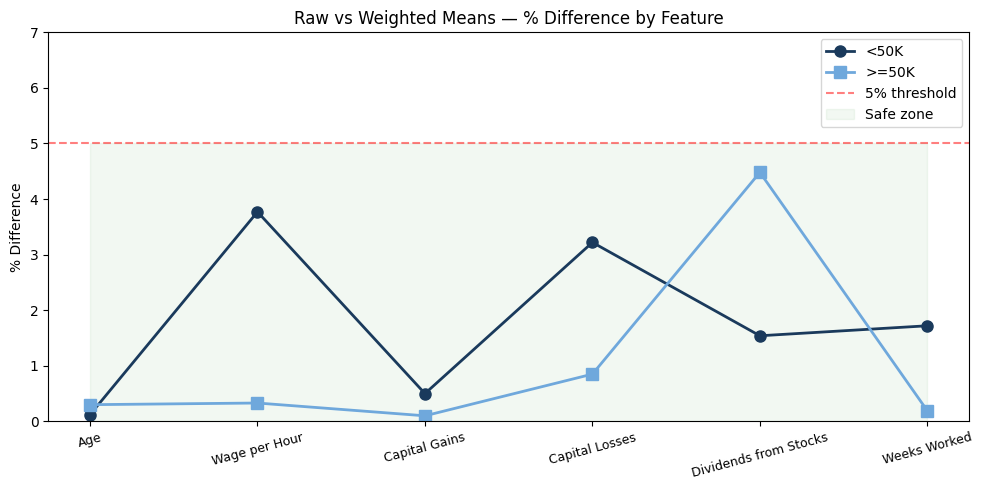

In [2]:
import matplotlib.pyplot as plt
import numpy as np

features = ['Age', 'Wage per Hour', 'Capital Gains',
            'Capital Losses', 'Dividends from Stocks', 'Weeks Worked']

pct_diff_0 = [0.12, 3.77, 0.50, 3.22, 1.54, 1.72]  # <50K
pct_diff_1 = [0.30, 0.33, 0.10, 0.85, 4.48, 0.19]  # >=50K

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(features))

ax.plot(x, pct_diff_0, 'o-', color='#1a3a5c',
        linewidth=2, markersize=8, label='<50K')
ax.plot(x, pct_diff_1, 's-', color='#6fa8dc',
        linewidth=2, markersize=8, label='>=50K')
ax.axhline(y=5, color='red', linestyle='--',
           alpha=0.5, label='5% threshold')

ax.fill_between(x, 0, 5, alpha=0.05, color='green',
                label='Safe zone')

ax.set_xticks(x)
ax.set_xticklabels(features, rotation=15, fontsize=9)
ax.set_ylabel('% Difference')
ax.set_title('Raw vs Weighted Means — % Difference by Feature')
ax.legend()
ax.set_ylim(0, 7)

plt.tight_layout()
plt.show()

NUM OF PERSONS WORKED FOR THE EMPLOYER - IS THE COMPANY A BIG TECH OR SMALL COMPANY

In [ ]:
print("Num Persons Worked For Employer Statistics:")
print(df['num persons worked for employer'].describe())

print("\nUnique values and counts:")
print(df['num persons worked for employer'].value_counts().sort_index())

print("\nDistribution among income groups:")
print(df.groupby('label')['num persons worked for employer'].value_counts().unstack())

Num Persons Worked For Employer Statistics:
count    199523.000000
mean          1.956180
std           2.365126
min           0.000000
25%           0.000000
50%           1.000000
75%           4.000000
max           6.000000
Name: num persons worked for employer, dtype: float64

Unique values and counts:
num persons worked for employer
0    95983
1    23109
2    10081
3    13425
4    14379
5     6035
6    36511
Name: count, dtype: int64

Distribution among income groups:
num persons worked for employer      0      1     2      3      4     5      6
label                                                                         
0                                95387  21016  9243  12185  12909  5370  31031
1                                  596   2093   838   1240   1470   665   5480


In [ ]:
df['num persons worked for employer']

,num persons worked for employer
0,0
1,1
2,0
3,0
4,0
...,...
199518,0
199519,1
199520,6
199521,0


Weeks Worked In Year Analysis:

In [ ]:
print("Weeks Worked In Year Statistics:")
print(df['weeks worked in year'].describe())

print("\nHow many people worked zero weeks?")
print((df['weeks worked in year'] == 0).sum())
print("Percentage:", (df['weeks worked in year'] == 0).sum() / len(df) * 100)

print("\nHow many people worked full year (52 weeks)?")
print((df['weeks worked in year'] == 52).sum())
print("Percentage:", (df['weeks worked in year'] == 52).sum() / len(df) * 100)

print("\nDistribution among income groups:")
print(df.groupby('label')['weeks worked in year'].describe())

Weeks Worked In Year Statistics:
count    199523.000000
mean         23.174897
std          24.411488
min           0.000000
25%           0.000000
50%           8.000000
75%          52.000000
max          52.000000
Name: weeks worked in year, dtype: float64

How many people worked zero weeks?
95983
Percentage: 48.106233366579296

How many people worked full year (52 weeks)?
70314
Percentage: 35.24104990402109

Distribution among income groups:
          count       mean        std  min   25%   50%   75%   max
label                                                             
0      187141.0  21.527762  24.118209  0.0   0.0   0.0  52.0  52.0
1       12382.0  48.069617  12.259412  0.0  52.0  52.0  52.0  52.0


/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


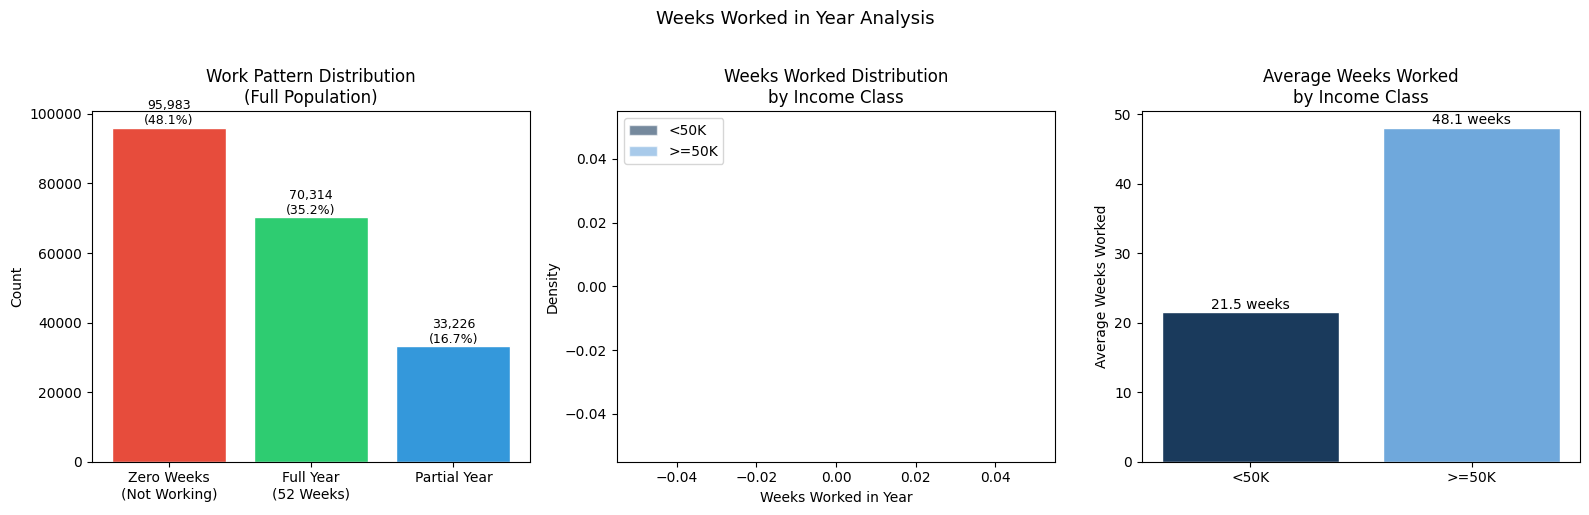

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Zero vs Full year vs Other
categories = ['Zero Weeks\n(Not Working)', 'Full Year\n(52 Weeks)', 'Partial Year']
partial = len(df) - 95983 - 70314
values = [95983, 70314, partial]
colors = ['#e74c3c', '#2ecc71', '#3498db']

axes[0].bar(categories, values, color=colors, edgecolor='white')
axes[0].set_title('Work Pattern Distribution\n(Full Population)')
axes[0].set_ylabel('Count')
for i, v in enumerate(values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                ha='center', fontsize=9)

# Plot 2: Distribution of weeks worked by income class
for label, color, name in [(0, '#1a3a5c', '<50K'), (1, '#6fa8dc', '>=50K')]:
    data = df[df['label']==label]['weeks worked in year']
    axes[1].hist(data, bins=30, alpha=0.6,
                color=color, label=name, density=True,
                edgecolor='white')
axes[1].set_title('Weeks Worked Distribution\nby Income Class')
axes[1].set_xlabel('Weeks Worked in Year')
axes[1].set_ylabel('Density')
axes[1].legend()

# Plot 3: Average weeks worked by income class
avg_weeks = df.groupby('label')['weeks worked in year'].mean()
bars = axes[2].bar(['<50K', '>=50K'], avg_weeks.values,
                   color=['#1a3a5c', '#6fa8dc'],
                   edgecolor='white')
axes[2].set_title('Average Weeks Worked\nby Income Class')
axes[2].set_ylabel('Average Weeks Worked')
for i, v in enumerate(avg_weeks.values):
    axes[2].text(i, v + 0.5, f'{v:.1f} weeks',
                ha='center', fontsize=10)

plt.suptitle('Weeks Worked in Year Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Key insight for client:

The single strongest predictor of earning >$50k is working full year (52 weeks). 75% of high earners work all 52 weeks compared to 50% of low earners working zero weeks.

##CATEGORICAL COLUMNS

In [55]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_cols)
print("Count:", len(cat_cols))

Categorical columns: ['class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'live in this house 1 year ago', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', "fill inc questionnaire for veteran's admin"]
Count: 24


In [56]:
for col in cat_cols:
    print(f"\n{col}:")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts().head(3))
    print("---")


class of worker:
Unique values: 9
class of worker
Not in universe                   100245
Private                            72028
Self-employed-not incorporated      8445
Name: count, dtype: int64
---

education:
Unique values: 17
education
High school graduate          48407
Children                      47422
Some college but no degree    27820
Name: count, dtype: int64
---

enroll in edu inst last wk:
Unique values: 3
enroll in edu inst last wk
Not in universe          186943
High school                6892
College or university      5688
Name: count, dtype: int64
---

marital stat:
Unique values: 7
marital stat
Never married                      86485
Married-civilian spouse present    84222
Divorced                           12710
Name: count, dtype: int64
---

major industry code:
Unique values: 24
major industry code
Not in universe or children    100684
Retail trade                    17070
Manufacturing-durable goods      9015
Name: count, dtype: int64
---

major occupation

# Check % high earners for key categorical columns

In [57]:
# Check % high earners for key categorical columns
key_cols = ['education', 'class of worker',
            'marital stat', 'major occupation code',
            'sex', 'race', 'citizenship', 'tax filer stat']

for col in key_cols:
    print(f"\n{col}:")
    income = df.groupby(col)['label'].value_counts(normalize=True).unstack()
    income.columns = ['<50k', '>50k']
    income['pct_high_income'] = income['>50k'] * 100
    print(income['pct_high_income'].sort_values(ascending=False))
    print("---")


education:
education
Prof school degree (MD DDS DVM LLB JD)    54.043503
Doctorate degree(PhD EdD)                 52.019002
Masters degree(MA MS MEng MEd MSW MBA)    31.157315
Bachelors degree(BA AB BS)                19.708029
Associates degree-academic program         9.443044
Associates degree-occup /vocational        7.708100
Some college but no degree                 6.423436
High school graduate                       3.881670
12th grade no diploma                      1.599247
11th grade                                 1.018034
7th and 8th grade                          0.899213
10th grade                                 0.820431
1st 2nd 3rd or 4th grade                   0.722624
5th or 6th grade                           0.671346
9th grade                                  0.609952
Less than 1st grade                        0.122100
Children                                        NaN
Name: pct_high_income, dtype: float64
---

class of worker:
class of worker
Self-employed-inco

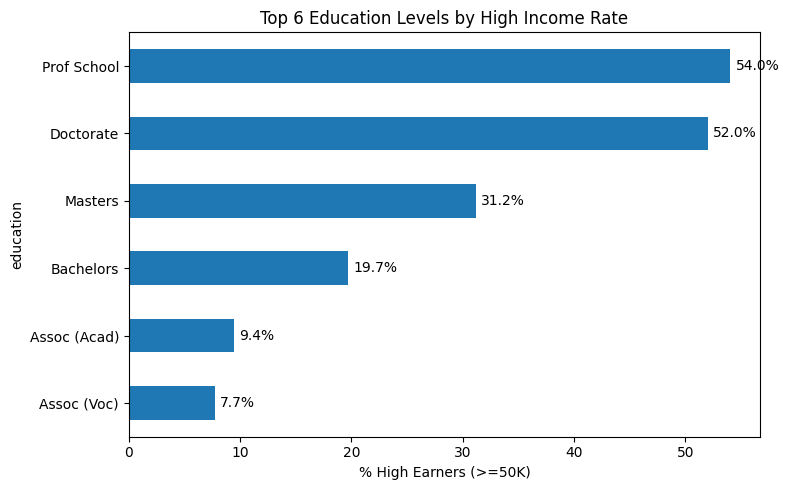

In [61]:
# Create mapping
edu_map = {
    'Prof school degree (MD DDS DVM LLB JD)': 'Prof School',
    'Doctorate degree(PhD EdD)': 'Doctorate',
    'Masters degree(MA MS MEng MEd MSW MBA)': 'Masters',
    'Bachelors degree(BA AB BS)': 'Bachelors',
    'Associates degree-academic program': 'Assoc (Acad)',
    'Associates degree-occup /vocational': 'Assoc (Voc)'
}

# Apply mapping
top_edu_short = top_edu.copy()
top_edu_short.index = top_edu_short.index.map(edu_map)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
top_edu_short.sort_values().plot(kind='barh')

plt.xlabel('% High Earners (>=50K)')
plt.title('Top 6 Education Levels by High Income Rate')

# Add labels
for i, v in enumerate(top_edu_short.sort_values()):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()

In [ ]:
remaining_cols = [
    'enroll in edu inst last wk',
    'member of a labor union',
    'reason for unemployment',
    'region of previous residence',
    'live in this house 1 year ago',
    'fill inc questionnaire for veteran\'s admin',
    'country of birth father',
    'country of birth mother',
    'country of birth self',
    'detailed household and family stat',
    'detailed household summary in household',
    'state of previous residence',
    'family members under 18'
]

for col in remaining_cols:
    print(f"\n{col}:")
    print(f"Unique values: {df[col].nunique()}")
    income = df.groupby(col)['label'].value_counts(normalize=True).unstack()
    income.columns = ['<50k', '>50k']
    income['pct_high_income'] = income['>50k'] * 100
    print(income['pct_high_income'].sort_values(ascending=False))
    print("---")


enroll in edu inst last wk:
Unique values: 3
enroll in edu inst last wk
Not in universe          6.607362
College or university    0.439522
High school              0.072548
Name: pct_high_income, dtype: float64
---

member of a labor union:
Unique values: 3
member of a labor union
Yes                13.597360
No                 11.363353
Not in universe     5.623438
Name: pct_high_income, dtype: float64
---

reason for unemployment:
Unique values: 6
reason for unemployment
Not in universe          6.312644
Other job loser          4.857704
Job leaver               4.013378
Job loser - on layoff    2.254098
Re-entrant               1.139178
New entrant              0.455581
Name: pct_high_income, dtype: float64
---

region of previous residence:
Unique values: 6
region of previous residence
Not in universe    6.402177
Northeast          5.434381
West               3.927344
South              3.763551
Abroad             3.396226
Midwest            3.048951
Name: pct_high_income, dtype:

In [ ]:
# Check correlation between numerical columns
print("Correlation with label:")
print(df[['age', 'wage per hour', 'capital gains',
          'capital losses', 'dividends from stocks',
          'weeks worked in year',
          'num persons worked for employer',
          'label']].corr()['label'].sort_values(ascending=False))

Correlation with label:
label                              1.000000
weeks worked in year               0.262316
capital gains                      0.240725
num persons worked for employer    0.222684
dividends from stocks              0.175779
capital losses                     0.147417
age                                0.135720
wage per hour                      0.024528
Name: label, dtype: float64


In [ ]:
# Check if any numerical columns are correlated with each other
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['age', 'wage per hour', 'capital gains',
            'capital losses', 'dividends from stocks',
            'weeks worked in year',
            'num persons worked for employer']

corr_matrix = df[num_cols].corr()
print(corr_matrix)

                                      age  wage per hour  capital gains  \
age                              1.000000       0.036938       0.053590   
wage per hour                    0.036938       1.000000      -0.001082   
capital gains                    0.053590      -0.001082       1.000000   
capital losses                   0.063351       0.010993      -0.012700   
dividends from stocks            0.104976      -0.005731       0.131476   
weeks worked in year             0.206181       0.195687       0.083549   
num persons worked for employer  0.140887       0.191543       0.058015   

                                 capital losses  dividends from stocks  \
age                                    0.063351               0.104976   
wage per hour                          0.010993              -0.005731   
capital gains                         -0.012700               0.131476   
capital losses                         1.000000               0.042427   
dividends from stocks        

# Check outliers in all numerical columns

In [18]:
# Check outliers in all numerical columns
num_cols = ['age', 'wage per hour', 'capital gains',
            'capital losses', 'dividends from stocks',
            'weeks worked in year',
            'num persons worked for employer']

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n{col}:")
    print(f"  Lower bound: {lower}")
    print(f"  Upper bound: {upper}")
    print(f"  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")


age:
  Lower bound: -37.5
  Upper bound: 102.5
  Outliers: 0 (0.00%)

wage per hour:
  Lower bound: 0.0
  Upper bound: 0.0
  Outliers: 11304 (5.67%)

capital gains:
  Lower bound: 0.0
  Upper bound: 0.0
  Outliers: 7379 (3.70%)

capital losses:
  Lower bound: 0.0
  Upper bound: 0.0
  Outliers: 3906 (1.96%)

dividends from stocks:
  Lower bound: 0.0
  Upper bound: 0.0
  Outliers: 21141 (10.60%)

weeks worked in year:
  Lower bound: -78.0
  Upper bound: 130.0
  Outliers: 0 (0.00%)

num persons worked for employer:
  Lower bound: -6.0
  Upper bound: 10.0
  Outliers: 0 (0.00%)


In [ ]:
# Only look at non-zero values for financial columns
financial_cols = ['wage per hour', 'capital gains',
                  'capital losses', 'dividends from stocks']

for col in financial_cols:
    non_zero = df[df[col] > 0][col]
    print(f"\n{col} (non-zero values only):")
    print(f"  Count non-zero: {len(non_zero)} ({len(non_zero)/len(df)*100:.2f}%)")
    print(f"  Min: {non_zero.min()}")
    print(f"  Max: {non_zero.max()}")
    print(f"  Mean: {non_zero.mean():.2f}")
    print(f"  Median: {non_zero.median():.2f}")
    print(f"  99th percentile: {non_zero.quantile(0.99):.2f}")
    print(f"  99.9th percentile: {non_zero.quantile(0.999):.2f}")


wage per hour (non-zero values only):
  Count non-zero: 11304 (5.67%)
  Min: 20
  Max: 9999
  Mean: 978.32
  Median: 800.00
  99th percentile: 3000.00
  99.9th percentile: 8000.00

capital gains (non-zero values only):
  Count non-zero: 7379 (3.70%)
  Min: 114
  Max: 99999
  Mean: 11754.50
  Median: 5178.00
  99th percentile: 99999.00
  99.9th percentile: 99999.00

capital losses (non-zero values only):
  Count non-zero: 3906 (1.96%)
  Min: 155
  Max: 4608
  Mean: 1906.03
  Median: 1887.00
  99th percentile: 3770.00
  99.9th percentile: 4379.94

dividends from stocks (non-zero values only):
  Count non-zero: 21141 (10.60%)
  Min: 1
  Max: 99999
  Mean: 1864.23
  Median: 301.00
  99th percentile: 25000.00
  99.9th percentile: 99999.00


In [ ]:
# Let's look at who this person is
high_wage_person = df[df['wage per hour'] == 9999]
print(high_wage_person[['age', 'class of worker', 'education',
                          'major occupation code', 'weeks worked in year',
                          'capital gains', 'dividends from stocks',
                          'label']].to_string())

        age class of worker                  education   major occupation code  weeks worked in year  capital gains  dividends from stocks  label
190936   46         Private  Doctorate degree(PhD EdD)  Professional specialty                    52              0                      0      1


##FEATURE ENGINEERING
##Create Feature 1 — Total Investment Income:

In [ ]:
# Create total investment income
df['total investment income'] = (df['capital gains'] -
                                  df['capital losses'] +
                                  df['dividends from stocks'])

# Verify
print("Total investment income statistics:")
print(df['total investment income'].describe())

print("\nMean by income group:")
print(df.groupby('label')['total investment income'].mean())

print("\nCorrelation with label:")
print(df['total investment income'].corr(df['label']))

Total investment income statistics:
count    199523.000000
mean        594.934734
std        5339.960948
min       -4608.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      199998.000000
Name: total investment income, dtype: float64

Mean by income group:
label
0     224.660801
1    6191.238572
Name: total investment income, dtype: float64

Correlation with label:
0.2695722724606996


In [ ]:
# Binary flag for any investment activity
df['has investment income'] = (df['total investment income'] > 0).astype(int)

# Verify
print("Feature 2 created — has investment income")
print(df['has investment income'].value_counts())

print("\nIncome distribution by investment activity:")
invest_income = df.groupby('has investment income')['label'].value_counts(normalize=True).unstack()
invest_income.columns = ['<50k', '>50k']
invest_income['pct_high_income'] = invest_income['>50k'] * 100
print(invest_income)

Feature 2 created — has investment income
has investment income
0    173832
1     25691
Name: count, dtype: int64

Income distribution by investment activity:
                           <50k      >50k  pct_high_income
has investment income                                     
0                      0.964356  0.035644         3.564361
1                      0.759215  0.240785        24.078471


In [ ]:
df['has investment income']

,has investment income
0,0
1,0
2,0
3,0
4,0
...,...
199518,0
199519,1
199520,1
199521,0


In [ ]:
# Create age groups
df['age group'] = pd.cut(df['age'],
                          bins=[0, 18, 25, 35, 45, 55, 65, 90],
                          labels=['under 18', '18-25', '25-35',
                                  '35-45', '45-55', '55-65', '65+'])

# Verify
print("Feature 3 created — age group")
print(df['age group'].value_counts())

print("\nIncome distribution by age group:")
age_income = df.groupby('age group')['label'].value_counts(normalize=True).unstack()
age_income.columns = ['<50k', '>50k']
age_income['pct_high_income'] = age_income['>50k'] * 100
print(age_income['pct_high_income'].sort_values(ascending=False))

Feature 3 created — age group
age group
under 18    55637
25-35       31556
35-45       30817
65+         22739
45-55       22082
18-25       18123
55-65       15730
Name: count, dtype: int64

Income distribution by age group:
age group
45-55       16.284757
35-45       13.112892
55-65       10.165289
25-35        6.746736
65+          3.720480
18-25        0.926999
under 18     0.005392
Name: pct_high_income, dtype: float64


/tmp/ipykernel_961/1689969281.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_income = df.groupby('age group')['label'].value_counts(normalize=True).unstack()


In [ ]:
# More nuanced approach
df['work intensity'] = pd.cut(df['weeks worked in year'],
                               bins=[-1, 0, 13, 26, 39, 52],
                               labels=['did not work',
                                       'very part time',
                                       'part time',
                                       'most of year',
                                       'full year'])

# Verify
print(df.groupby('work intensity')['label'].value_counts(normalize=True).unstack()
      [1].sort_values(ascending=False) * 100)

work intensity
full year         13.763905
most of year       3.761806
part time          2.171053
very part time     1.168592
did not work       0.620943
Name: 1, dtype: float64


/tmp/ipykernel_961/594923134.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('work intensity')['label'].value_counts(normalize=True).unstack()


In [ ]:
df['education']

,education
0,High school graduate
1,Some college but no degree
2,10th grade
3,Children
4,Children
...,...
199518,7th and 8th grade
199519,11th grade
199520,Some college but no degree
199521,10th grade


In [ ]:
# Create education ranking
education_ranking = {
    'Children': 0,
    'Less than 1st grade': 1,
    '1st 2nd 3rd or 4th grade': 2,
    '5th or 6th grade': 3,
    '7th and 8th grade': 4,
    '9th grade': 5,
    '10th grade': 6,
    '11th grade': 7,
    '12th grade no diploma': 8,
    'High school graduate': 9,
    'Some college but no degree': 10,
    'Associates degree-occup /vocational': 11,
    'Associates degree-academic program': 12,
    'Bachelors degree(BA AB BS)': 13,
    'Masters degree(MA MS MEng MEd MSW MBA)': 14,
    'Prof school degree (MD DDS DVM LLB JD)': 15,
    'Doctorate degree(PhD EdD)': 16
}

df['education rank'] = df['education'].map(education_ranking)

# Verify
print("Feature 5 created — education rank")
print(df['education rank'].value_counts().sort_index())

print("\nMean education rank by income group:")
print(df.groupby('label')['education rank'].mean())

print("\nCorrelation with label:")
print(df['education rank'].corr(df['label']))

Feature 5 created — education rank
education rank
0     47422
1       819
2      1799
3      3277
4      8007
5      6230
6      7557
7      6876
8      2126
9     48407
10    27820
11     5358
12     4363
13    19865
14     6541
15     1793
16     1263
Name: count, dtype: int64

Mean education rank by income group:
label
0     6.730433
1    12.150460
Name: education rank, dtype: float64

Correlation with label:
0.276955056236927


##END OF DATA EXPLORATION